# 1. Đọc dữ liệu & Tổng quan

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from datetime import datetime as dt
import warnings

warnings.filterwarnings('ignore')


In [36]:
df = pd.read_csv('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/TREASURY STATMENT/DTS_PubDebtTrans_20200619_20250618.csv', parse_dates=['Record Date'])
print(f"Kích thước dữ liệu: {df.shape}")
print(f"Phạm vi thời gian: {df['Record Date'].min()} đến {df['Record Date'].max()}")

df.head()


Kích thước dữ liệu: (29987, 17)
Phạm vi thời gian: 2020-06-19 00:00:00 đến 2025-06-18 00:00:00


,Record Date,Transaction Type,Security Marketability,Security Type,Security Type Description,Transactions Today,Transactions Month to Date,Transactions Fiscal Year to Date,Table Number,Table Name,Source Line Number,Fiscal Year,Fiscal Quarter Number,Calendar Year,Calendar Quarter Number,Calendar Month Number,Calendar Day Number
0,2025-06-18,Issues,Marketable,Bills,Regular Series,-11,1025611,16246994,IIIA,Public Debt Transactions,1,2025,3,2025,2,6,18
1,2025-06-18,Issues,Marketable,Bills,Cash Management Series,0,0,1890040,IIIA,Public Debt Transactions,2,2025,3,2025,2,6,18
2,2025-06-18,Issues,Marketable,Notes,NaN,0,306790,2949821,IIIA,Public Debt Transactions,3,2025,3,2025,2,6,18
3,2025-06-18,Issues,Marketable,Bonds,NaN,0,40584,368566,IIIA,Public Debt Transactions,4,2025,3,2025,2,6,18
4,2025-06-18,Issues,Marketable,Inflation-Protected Securities Increment,NaN,213,3915,37797,IIIA,Public Debt Transactions,5,2025,3,2025,2,6,18


# 2. Kiểm tra dữ liệu thiếu & Chuẩn hóa

In [15]:
print("Missing Data:\n", df.isnull().sum())
df.info()


Missing Data:
 Record Date                             0
Transaction Type                        0
Security Marketability                  0
Security Type                           0
Security Type Description           24967
Transactions Today                      0
Transactions Month to Date              0
Transactions Fiscal Year to Date        0
Table Number                            0
Table Name                              0
Source Line Number                      0
Fiscal Year                             0
Fiscal Quarter Number                   0
Calendar Year                           0
Calendar Quarter Number                 0
Calendar Month Number                   0
Calendar Day Number                     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29987 entries, 0 to 29986
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Reco

# 3. Tổng quan & Phân tích cơ bản

In [16]:
df['Month'] = df['Record Date'].dt.to_period('M')
monthly_total = df.groupby(['Month', 'Transaction Type'])['Transactions Today'].sum().unstack()
monthly_total.index = monthly_total.index.astype(str)
monthly_total.head()


Transaction Type,Issues,Redemptions
Month,,
2020-06,4339894,4096323
2020-07,10952145,10904434
2020-08,10143050,9939163
2020-09,10193507,9976955
2020-10,10449478,10259392


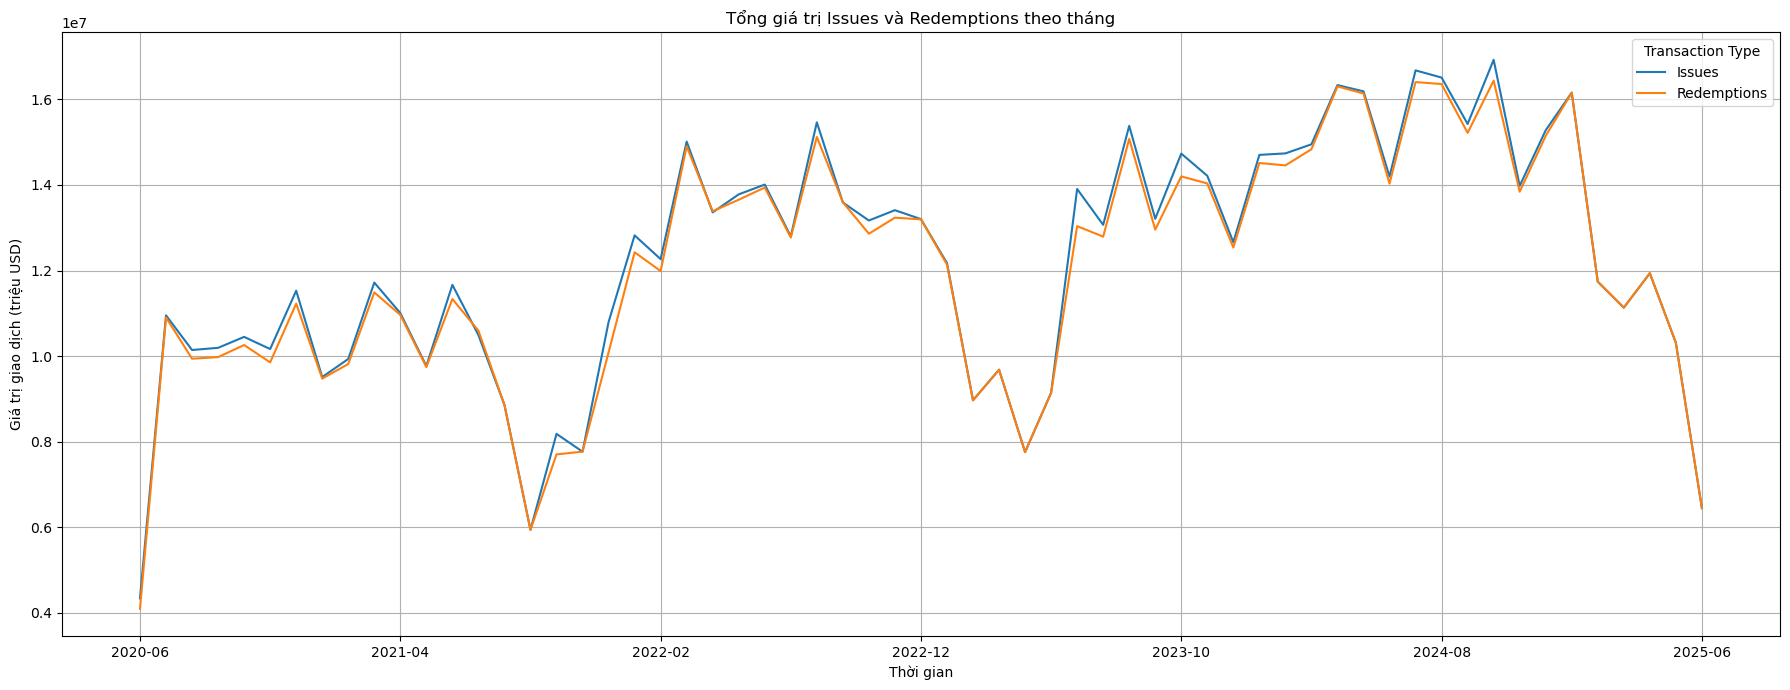

In [17]:
# Tổng giá trị giao dịch theo thời gian
plt.figure(figsize=(18, 7))
monthly_total.plot(ax=plt.gca())
plt.title('Tổng giá trị Issues và Redemptions theo tháng')
plt.ylabel('Giá trị giao dịch (triệu USD)')
plt.xlabel('Thời gian')
plt.grid(True)
plt.tight_layout()
plt.show()


# 4. Thống kê mô tả & Phân phối

Transaction Type         Issues    Redemptions
count                     61.00          61.00
mean              12,209,978.57  12,046,355.20
std                2,853,179.42   2,816,705.35
min                4,339,894.00   4,096,323.00
25%               10,193,507.00   9,976,955.00
50%               12,661,838.00  12,426,514.00
75%               14,213,424.00  14,034,339.00
max               16,924,097.00  16,437,178.00


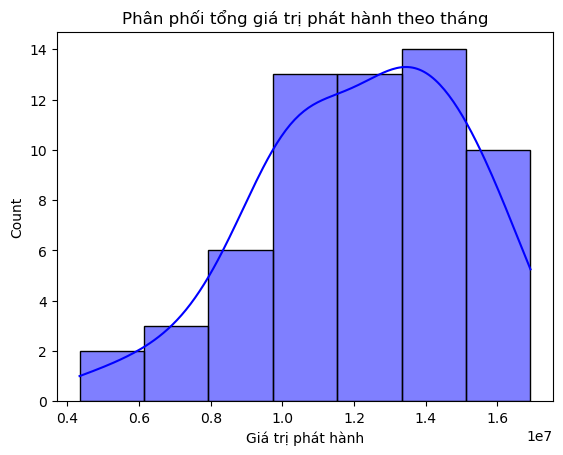

In [18]:
print(monthly_total.describe().applymap(lambda x: f"{x:,.2f}"))
sns.histplot(monthly_total['Issues'].dropna(), kde=True, color='blue')
plt.title('Phân phối tổng giá trị phát hành theo tháng')
plt.xlabel('Giá trị phát hành')
plt.show()


# 5. Phân tích chuỗi thời gian tổng Issues

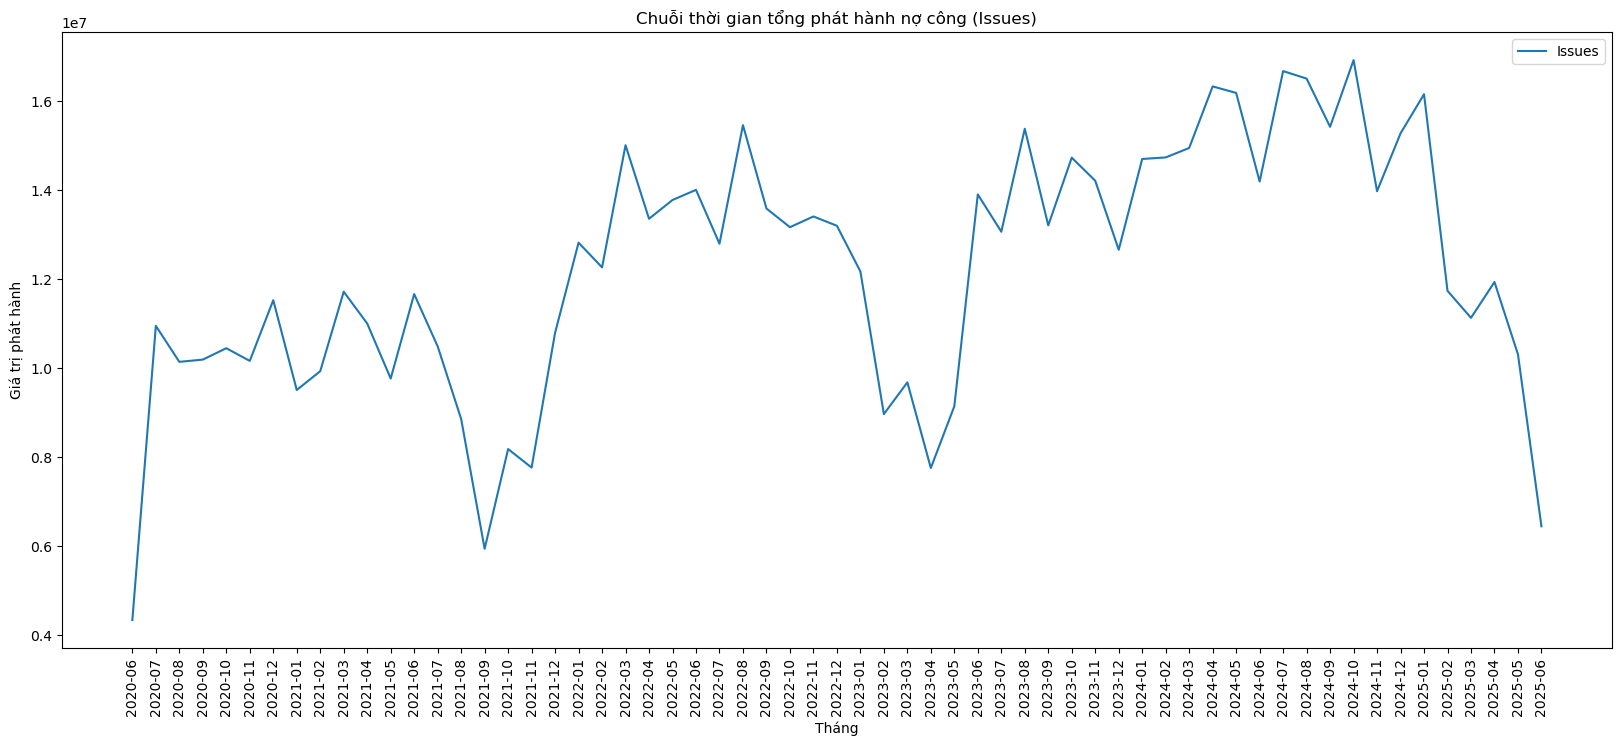

In [19]:
plt.figure(figsize=(20,8))
plt.plot(monthly_total.index, monthly_total['Issues'], label='Issues')
plt.title('Chuỗi thời gian tổng phát hành nợ công (Issues)')
plt.xlabel('Tháng')
plt.xticks(rotation=90)
plt.ylabel('Giá trị phát hành')
plt.legend()
plt.show()


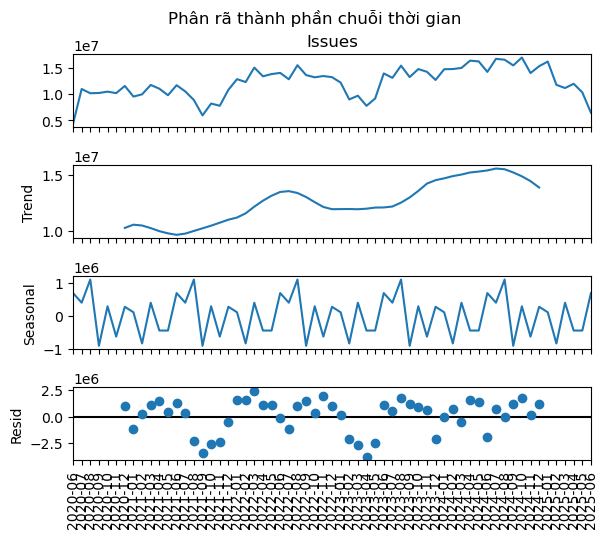

In [20]:
#Phân rã chuỗi thời gian (Trend & Seasonality)
decomposition = seasonal_decompose(monthly_total['Issues'].fillna(0), model='additive', period=12)
decomposition.plot()

plt.xticks(rotation=90)
plt.suptitle('Phân rã thành phần chuỗi thời gian', y=1.02)
plt.show()


# 6. Kiểm tra tính dừng (ADF Test)

In [34]:
result = adfuller(monthly_total['Issues'].fillna(0))

print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print(f"\t{key}: {value}")

if result[1] <= 0.05:
    print("Kết luận: Chuỗi thời gian là dừng")
else:
    print("Kết luận: Chuỗi thời gian không dừng")

ADF Statistic: -2.1172803678147494
p-value: 0.23762308826363915
	1%: -3.5506699942762414
	5%: -2.913766394626147
	10%: -2.5946240473991997
Kết luận: Chuỗi thời gian không dừng


# 7. ACF & PACF

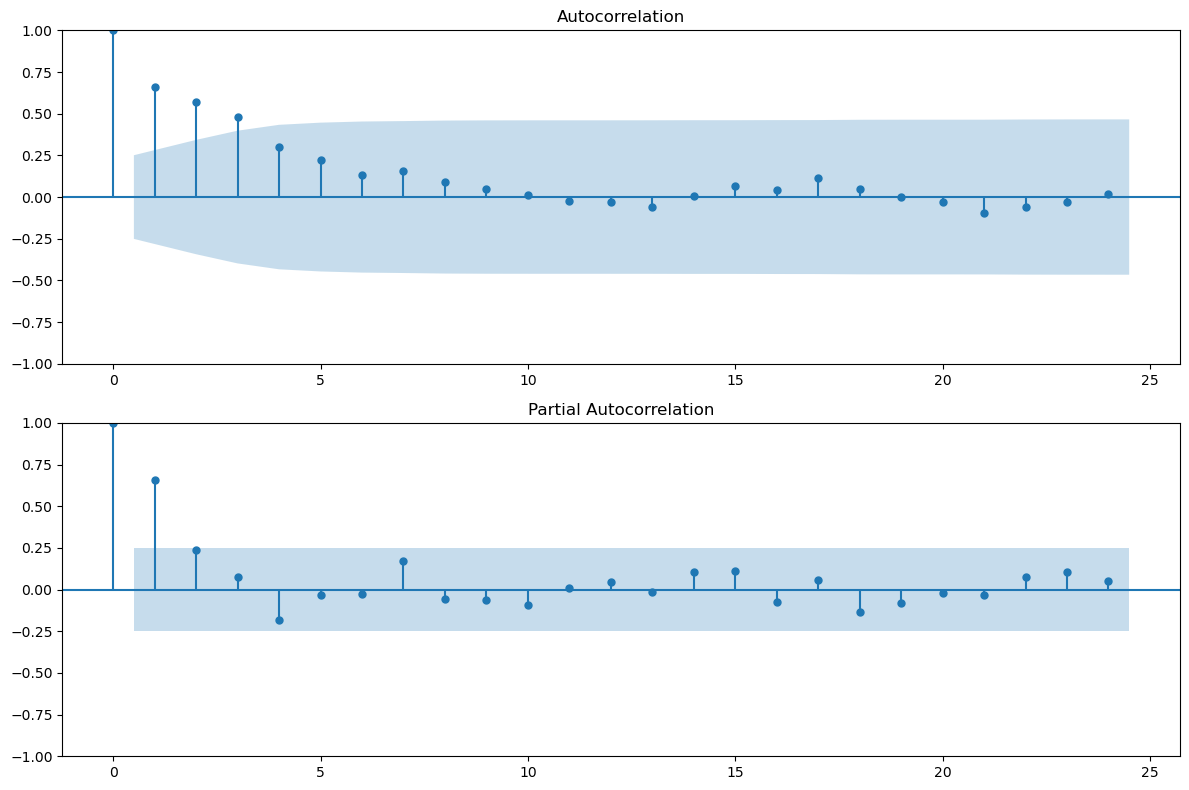

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(monthly_total['Issues'].fillna(0), lags=24, ax=ax1)
plot_pacf(monthly_total['Issues'].fillna(0), lags=24, ax=ax2)
plt.tight_layout()
plt.show()

# 8. Dự báo với ARIMA & SARIMA

In [23]:
ts = monthly_total['Issues'].fillna(0)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]


ARIMA - MSE: 15777330131300.322, MAE: 2841780.435474328


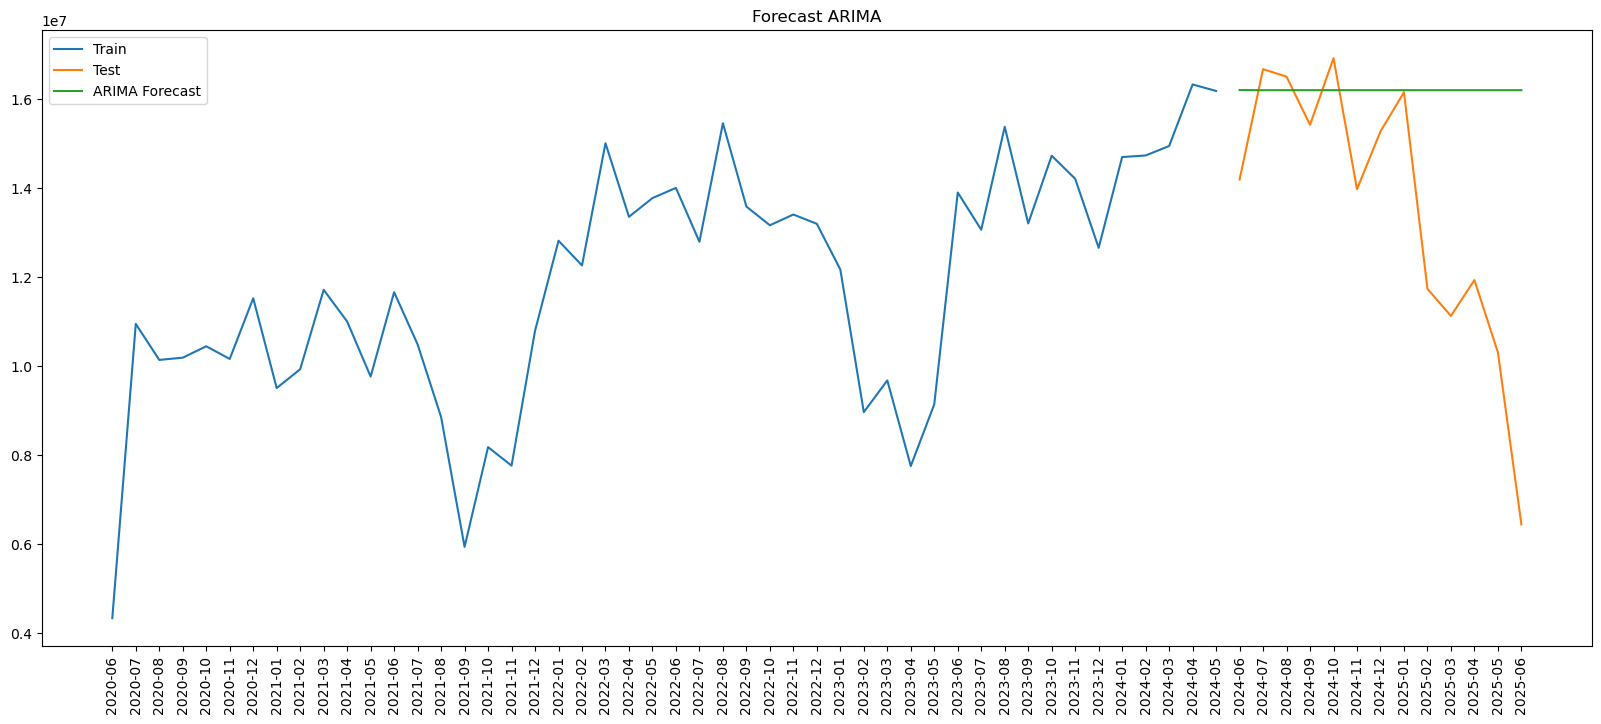

In [24]:
# ARIMA
arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))
mse = mean_squared_error(test, arima_forecast)
mae = mean_absolute_error(test, arima_forecast)
print(f"ARIMA - MSE: {mse}, MAE: {mae}")

plt.figure(figsize=(20,8))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.xticks(rotation=90)
plt.title('Forecast ARIMA')
plt.legend()
plt.show()


SARIMA - MSE: 42678107366179.8, MAE: 5486320.882266368


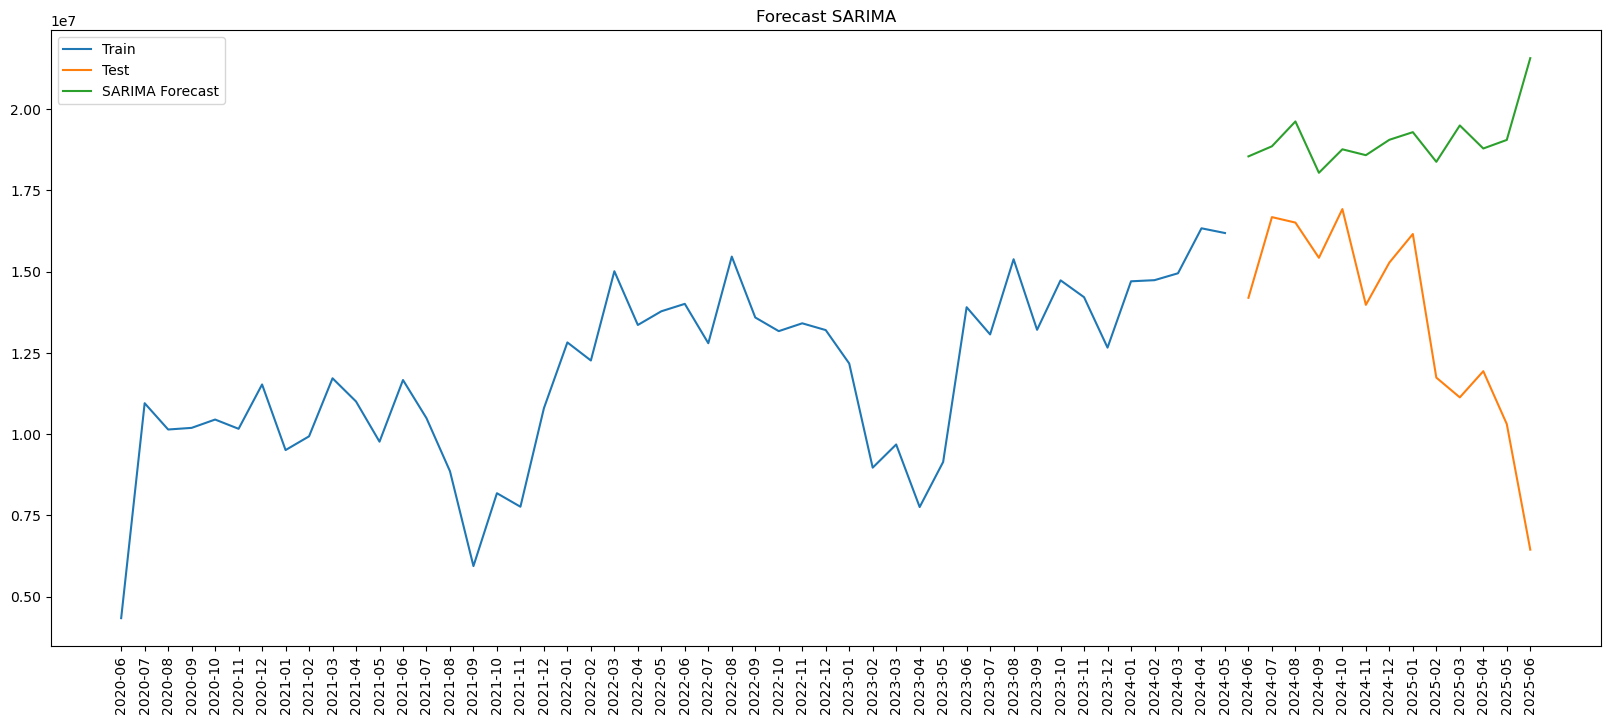

In [25]:
# SARIMA
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=len(test))
mse = mean_squared_error(test, sarima_forecast)
mae = mean_absolute_error(test, sarima_forecast)
print(f"SARIMA - MSE: {mse}, MAE: {mae}")

plt.figure(figsize=(20,8))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')
plt.xticks(rotation=90)
plt.title('Forecast SARIMA')
plt.legend()
plt.show()

#thêm khoảng tin cậy vô các đường dự báo

# So sánh mô hình

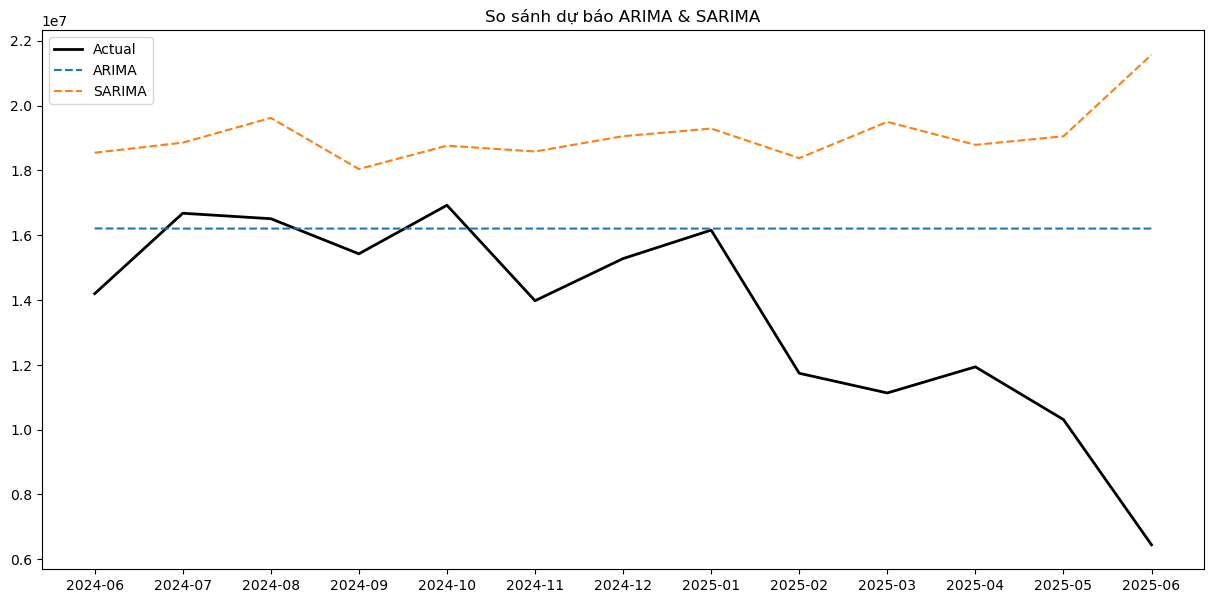

In [26]:
plt.figure(figsize=(15,7))
plt.plot(test.index, test, label='Actual', color='black', linewidth=2)
plt.plot(test.index, arima_forecast, label='ARIMA', linestyle='--')
plt.plot(test.index, sarima_forecast, label='SARIMA', linestyle='--')
plt.title('So sánh dự báo ARIMA & SARIMA')
plt.legend()
plt.show()


# 9. Dự báo 12 tháng tới với mô hình tốt nhất

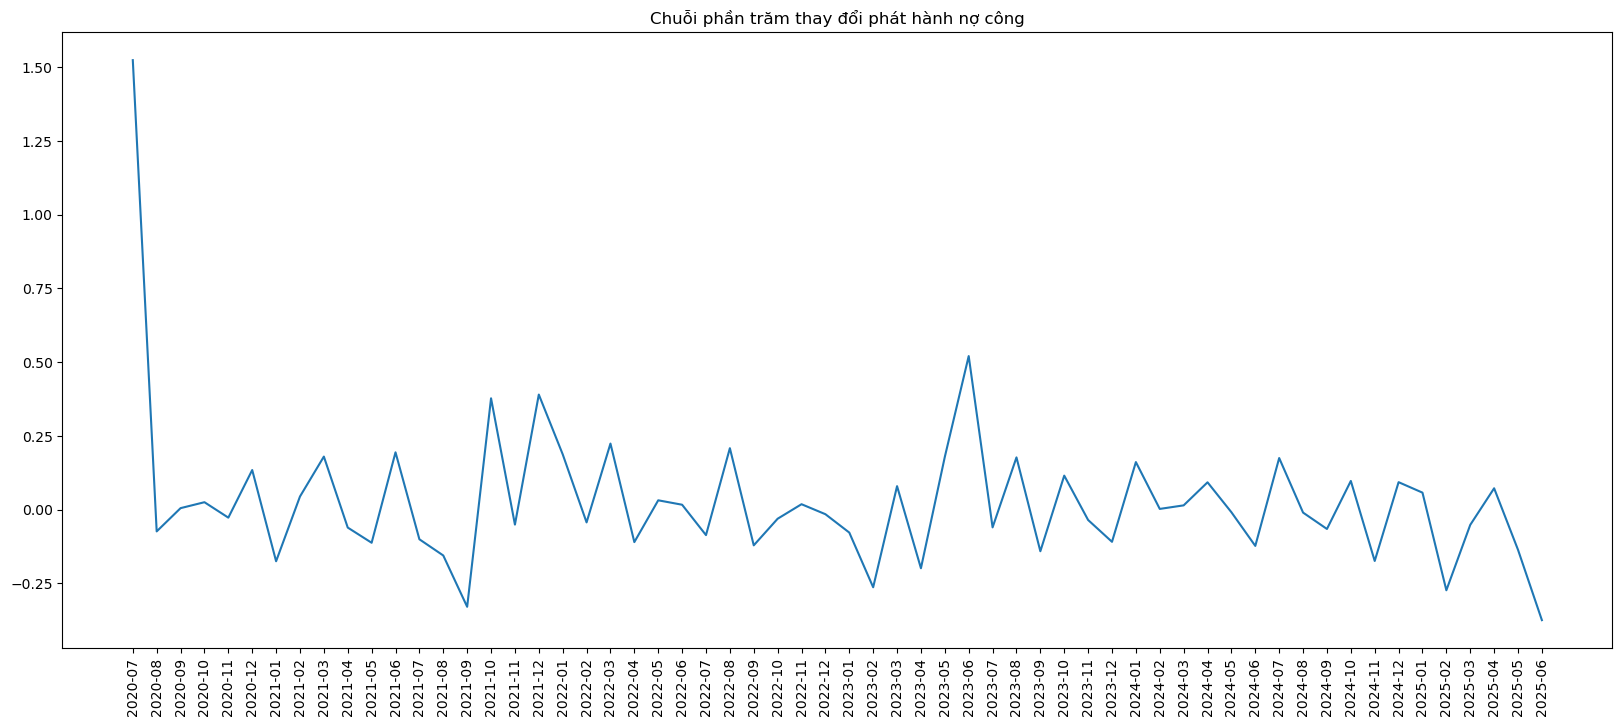

In [27]:
from arch import arch_model
import matplotlib.pyplot as plt
import pandas as pd

returns = ts.pct_change().dropna()  # Lấy log-returns nếu dữ liệu là giá, ở đây dùng phần trăm thay đổi
plt.figure(figsize=(20,8))
plt.plot(returns)
plt.xticks(rotation=90)
plt.title('Chuỗi phần trăm thay đổi phát hành nợ công')
plt.show()

In [28]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(returns)
print(f'p-value kiểm tra ARCH effect: {arch_test[1]}')

p-value kiểm tra ARCH effect: 0.9032040853099904


In [29]:
arch_mod = arch_model(returns, vol='ARCH', p=1)
arch_res = arch_mod.fit(disp='off')
print(arch_res.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 Issues   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                12.3425
Distribution:                  Normal   AIC:                          -18.6851
Method:            Maximum Likelihood   BIC:                          -12.4021
                                        No. Observations:                   60
Date:                Mon, Jun 23 2025   Df Residuals:                       59
Time:                        14:05:47   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0121  1.401e-02      0.866      0.387 

# ###forecast volatility

In [30]:
garch_mod = arch_model(returns, vol='GARCH', p=1, q=1)
garch_res = garch_mod.fit(disp='off')
print(garch_res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Issues   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                10.9444
Distribution:                  Normal   AIC:                          -13.8888
Method:            Maximum Likelihood   BIC:                          -5.51137
                                        No. Observations:                   60
Date:                Mon, Jun 23 2025   Df Residuals:                       59
Time:                        14:05:47   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0109  2.330e-02      0.467      0.640 

# ###forecast volatility

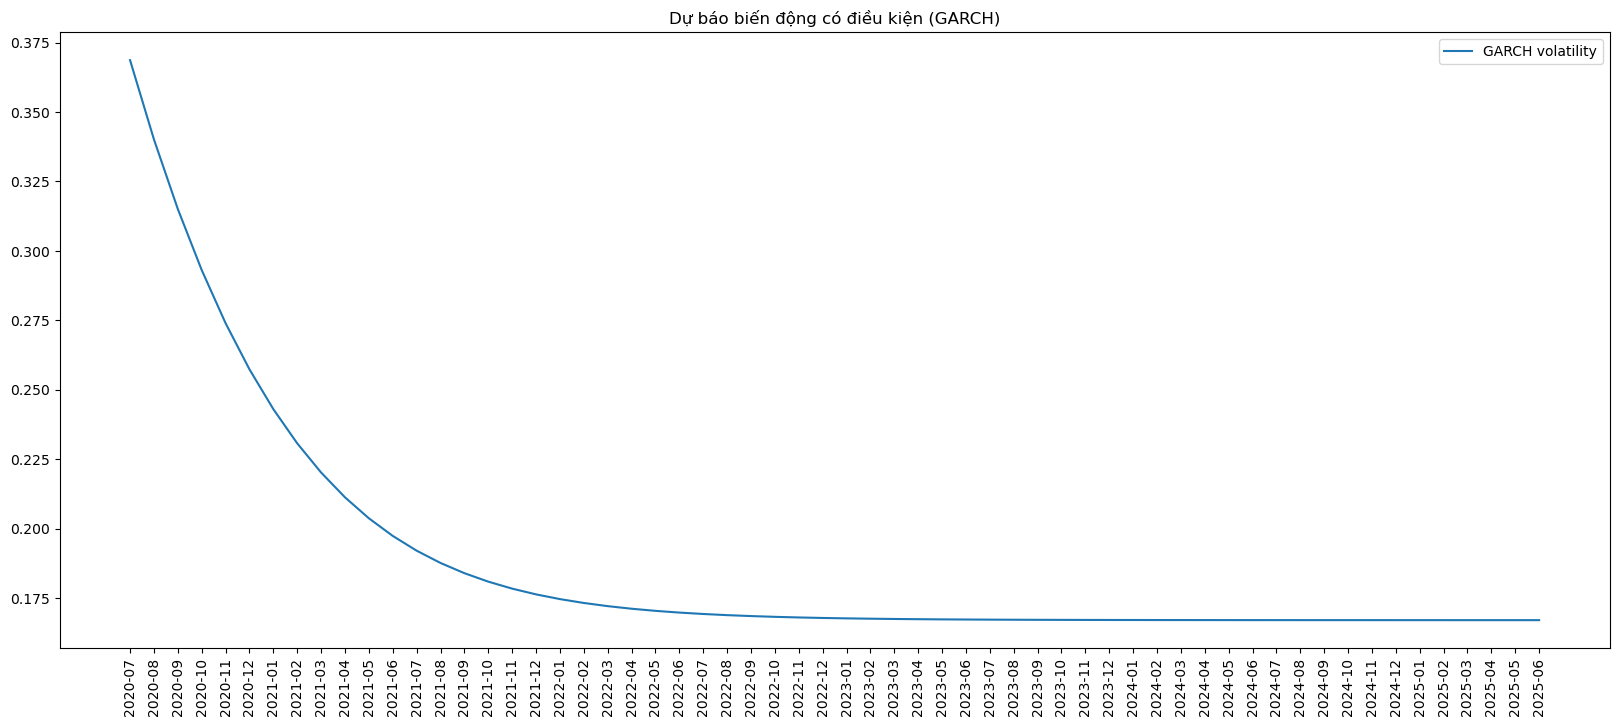

In [31]:
plt.figure(figsize=(20,8))
plt.plot(garch_res.conditional_volatility, label='GARCH volatility')
plt.title('Dự báo biến động có điều kiện (GARCH)')
plt.xticks(rotation=90)
plt.legend()
plt.show()